# Vectorization methods in TDA with giotto-tda

This tutorial explores key **vectorization techniques** for persistent homology:

**• Persistence Landscapes**  
**• Persistence Images**  
**• Betti Curves**  
**• Persistence Entropy**

**Datasets:** Noisy circle, concentric circles, Swiss roll

**Prepared by:** Ahana Mondal


In [1]:
# Setup

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles, make_swiss_roll, make_blobs
from sklearn.preprocessing import MinMaxScaler

from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import (
    PersistenceLandscape,
    PersistenceImage,
    BettiCurve,
    PersistenceEntropy,
    Scaler,
    Filtering,
)
from gtda.plotting import plot_diagram


# Utility function for nicer plots
plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["axes.grid"] = True

## 1. Synthetic datasets: circles and spheres

In this section, we generate simple point clouds whose topology is easy to interpret.
- A noisy circle in 2D has one dominant 1-dimensional hole.
- Two concentric noisy circles have two such holes.
- A noisy sphere-like cloud can be obtained from the swiss roll or blobs, and we will
  treat it as an example of higher-dimensional structure.[web:21]

### 1.1 Noisy circle

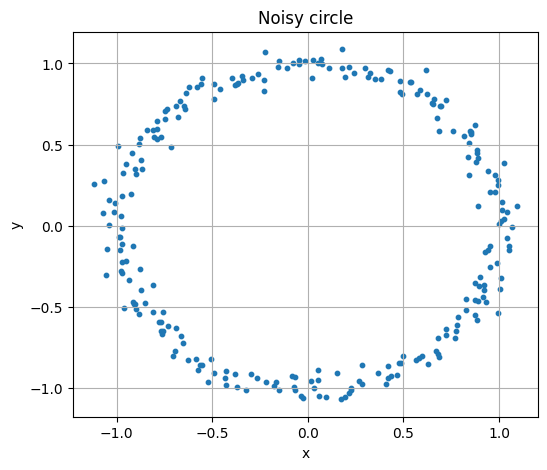

In [2]:
n_samples = 500
X_circle, y_circle = make_circles(
    n_samples=n_samples, factor=0.5, noise=0.05, random_state=0
)

mask_outer = (y_circle == 0)
X_outer = X_circle[mask_outer]

fig, ax = plt.subplots()
ax.scatter(X_outer[:, 0], X_outer[:, 1], s=10, c="tab:blue")
ax.set_title("Noisy circle")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

### 1.2 Concentric noisy circles

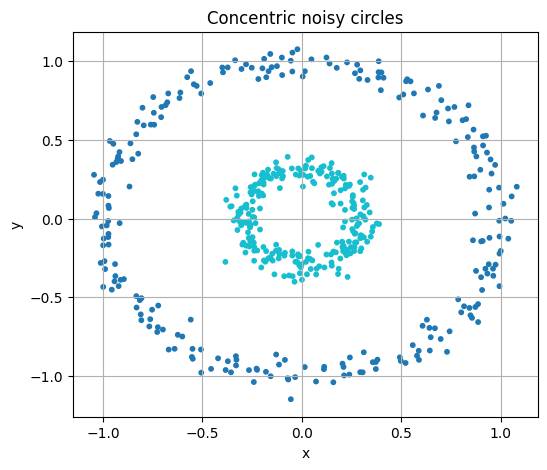

In [3]:
X_conc, y_conc = make_circles(
    n_samples=n_samples, factor=0.3, noise=0.05, random_state=1
)

fig, ax = plt.subplots()
ax.scatter(X_conc[:, 0], X_conc[:, 1], s=10, c=y_conc, cmap="tab10")
ax.set_title("Concentric noisy circles")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

### 1.3 Swiss-roll Dataset

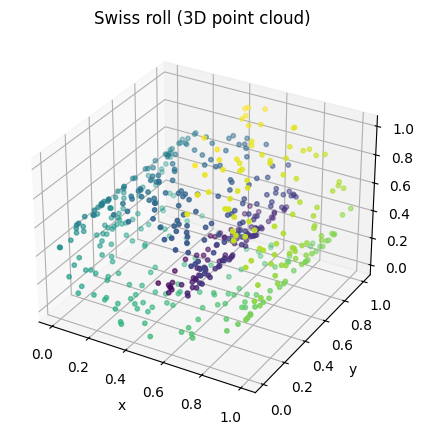

In [4]:
X_swiss, y_swiss = make_swiss_roll(n_samples=n_samples, noise=0.05, random_state=2)
X_swiss = MinMaxScaler().fit_transform(X_swiss)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=y_swiss, cmap="viridis", s=10)
ax.set_title("Swiss roll (3D point cloud)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.show()

## 2. Persistence diagrams with Vietoris–Rips

**Vietoris–Rips filtration** builds simplicial complexes from point clouds by connecting points within distance $r$:

r=0: Points (0-simplex)

r>0: Edges (distance ≤ r)

r++: Triangles, higher simplices


Persistence diagrams summarize the **birth and death** times of topological features across filtration scales $r$.

For each homology dimension $H_k$, points $(b,d)$ represent:
- **Birth time $b$**: Filtration value when $H_k$ feature appears
- **Death time $d$**: When feature disappears (merges/fills)  
- **Persistence $d-b$**: Lifespan/importance

**Key elements:**
- Diagonal ($b = d$): Infinitely short-lived features
- Above diagonal: Actual topological features  
- H0: Connected components
- H1: Loops/holes

**Vietoris–Rips → Diagrams**: Track homology as filtration parameter $r$ grows!

In [5]:
VR = VietorisRipsPersistence(
    homology_dimensions=[0, 1],
    metric="euclidean",
    n_jobs=-1,
)

# Wrap datasets in lists so that giotto-tda expects shape (n_samples, n_points, n_features)
X_circle_batch = [X_circle]
X_conc_batch = [X_conc]
X_swiss_batch = [X_swiss]

diagrams_circle = VR.fit_transform(X_circle_batch)
diagrams_conc = VR.fit_transform(X_conc_batch)
diagrams_swiss = VR.fit_transform(X_swiss_batch)

# Plot one diagram for each dataset
for name, D in [
    ("Noisy circle", diagrams_circle),
    ("Concentric circles", diagrams_conc),
    ("Swiss roll", diagrams_swiss),
]:
    fig = plot_diagram(D[0])
    fig.update_layout(title_text=f"Persistence diagram: {name}")
    fig.show()

## 3. Persistence landscapes

### 3.1 Concept

Persistence landscapes convert diagrams into **piecewise-linear functions** (tent functions).

**Construction:**
1. For each $(b,d)$, create tent: $\lambda(t) = \min(t-b, d-t, \frac{d-b}{2})$
2. **k-th landscape** = k-th largest tent value at each $t$
3. Vectorize: Sample at fixed grid points

**Interpretation:**
- Layer 1: Most prominent features
- Layer 2+: Successively less prominent features

**Strengths:** Stable, ranked importance, fixed vector size

In [6]:
# Compute landscapes
PL = PersistenceLandscape(
    n_layers=3,
    n_bins=100,
    n_jobs=-1,
)

PL_circle = PL.fit_transform(diagrams_circle)
PL_conc = PL.fit_transform(diagrams_conc)
PL_swiss = PL.fit_transform(diagrams_swiss)

print("Persistence landscape shape (circle):", PL_circle.shape)

Persistence landscape shape (circle): (1, 6, 100)


### 3.2 Visualizing persistence landscapes

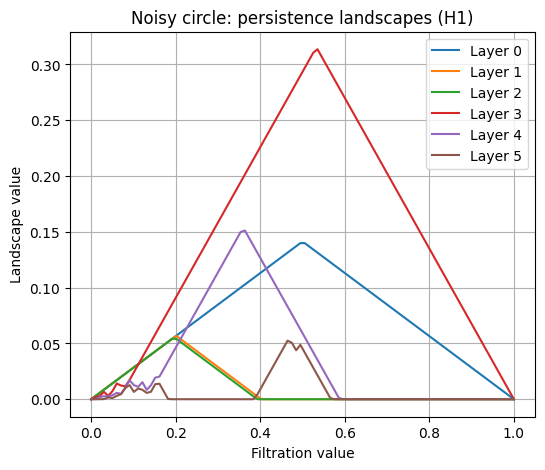

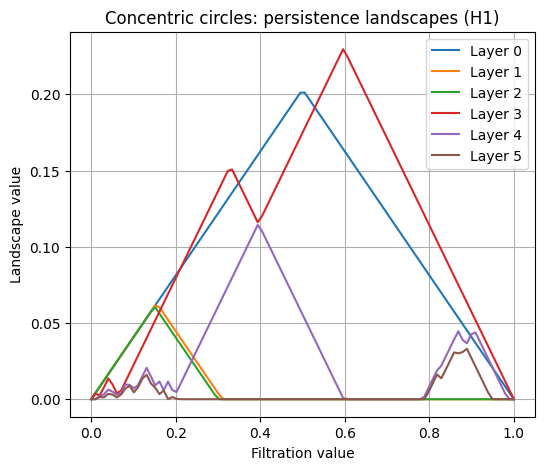

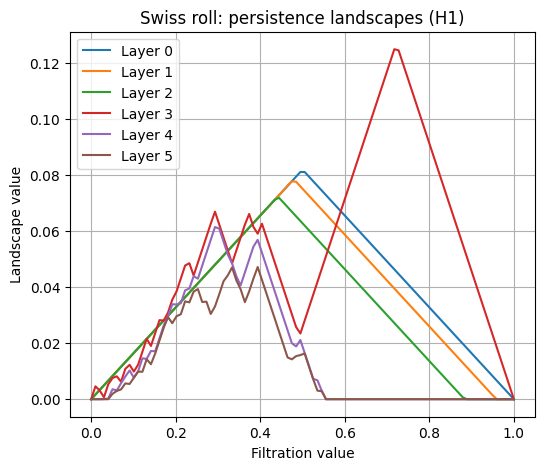

In [7]:
def plot_landscape(landscapes, hom_dim=1, sample=0, title="Persistence landscape"):
    """
    landscapes: output of PersistenceLandscape.fit_transform
    Expected shape is (n_samples, n_layers, n_bins) OR
    (n_samples, n_homology_dimensions, n_layers, n_bins).
    This function handles both.
    """
    arr = landscapes[sample]  # drop sample axis

    # If there is a homology dimension axis, select it
    if arr.ndim == 3:
        # shape (n_homology_dimensions, n_layers, n_bins)
        arr = arr[hom_dim]   # (n_layers, n_bins)
    elif arr.ndim == 2:
        # shape (n_layers, n_bins)
        pass
    else:
        raise ValueError(f"Unexpected landscape shape per sample: {arr.shape}")

    n_layers, n_bins = arr.shape
    xs = np.linspace(0, 1, n_bins)

    fig, ax = plt.subplots()
    for layer in range(n_layers):
        ax.plot(xs, arr[layer], label=f"Layer {layer}")
    ax.set_xlabel("Filtration value")
    ax.set_ylabel("Landscape value")
    ax.set_title(title + f" (H{hom_dim})")
    ax.legend()
    plt.show()

plot_landscape(PL_circle, hom_dim=1, title="Noisy circle: persistence landscapes")
plot_landscape(PL_conc, hom_dim=1, title="Concentric circles: persistence landscapes")
plot_landscape(PL_swiss, hom_dim=1, title="Swiss roll: persistence landscapes")

## 4. Persistence images

### 4.1 Concept

Persistence images **rasterize** diagrams into 2D density images.

**Steps:**
1. Transform $(b,d) → (b, d-b)$ [persistence coordinates]
2. Gaussian blur each point ($\sigma ∝$ persistence)
3. Bin into pixel grid → 2D image
4. Flatten → feature vector

**Advantages:**
- CNN-friendly 2D representation
- Translation-invariant
- Robust to perturbations

In [8]:
PI = PersistenceImage(
    n_bins=50,
    sigma=0.1,
    n_jobs=-1,
)

PI_circle = PI.fit_transform(diagrams_circle)
PI_conc = PI.fit_transform(diagrams_conc)
PI_swiss = PI.fit_transform(diagrams_swiss)

print("Persistence image shape (circle):", PI_circle.shape)

Persistence image shape (circle): (1, 2, 50, 50)


### 4.2 Visualizing persistence images

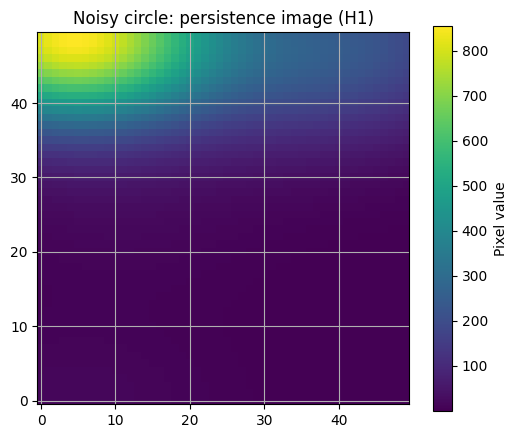

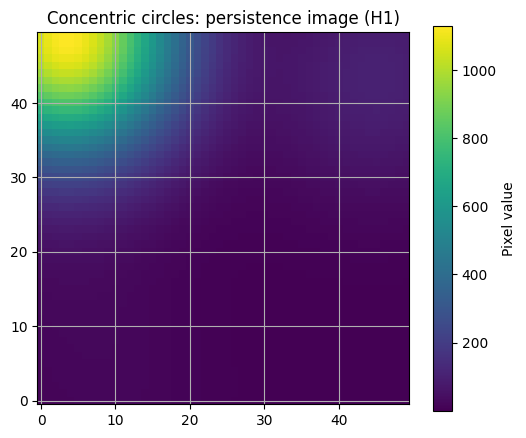

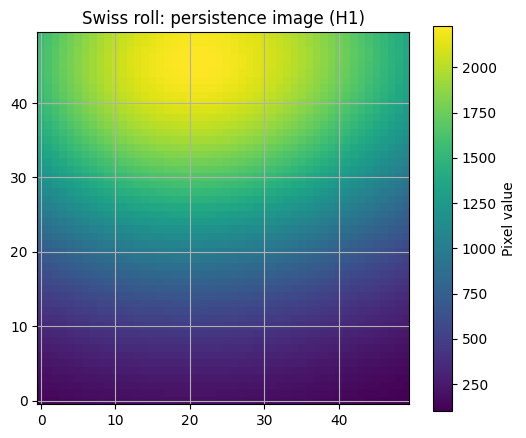

In [9]:
def plot_persistence_image(images, hom_dim=1, sample=0, title="Persistence image"):
    """
    images: array of shape (n_samples, n_homology_dimensions, n_bins, n_bins)
    """
    img = images[sample, hom_dim]
    fig, ax = plt.subplots()
    cax = ax.imshow(img, origin="lower", cmap="viridis")
    ax.set_title(title + f" (H{hom_dim})")
    fig.colorbar(cax, ax=ax, label="Pixel value")
    plt.show()


plot_persistence_image(PI_circle, hom_dim=1, title="Noisy circle: persistence image")
plot_persistence_image(PI_conc, hom_dim=1, title="Concentric circles: persistence image")
plot_persistence_image(PI_swiss, hom_dim=1, title="Swiss roll: persistence image")

## 5. Betti curves

### 5.1 Concept

Betti curves track the **number of topological features alive** at each filtration scale.

For dimension $k$, $\beta_k(t)$ = number of $H_k$ features with **birth ≤ t < death**:

$$
\beta_k(t) = |\{(b,d) \in D_k \mid b \leq t < d\}|
$$

**Key properties:**
- **H0 curve**: Starts high (n_points), decreases (merging)
- **H1 curve**: Starts 0, peaks (loops form), decreases (loops fill)  
- **Peak height** = max # simultaneous features
- **Peak location** = characteristic scale

**Advantages:**
- Simple time series of topological evolution
- Multi-scale summary in fixed-length vector
- Interpretable: See topology "come alive then die"

**Perfect for tracking topological lifespan across scales!**

In [10]:
BC = BettiCurve(n_bins=100, n_jobs=-1)

BC_circle = BC.fit_transform(diagrams_circle)
BC_conc = BC.fit_transform(diagrams_conc)
BC_swiss = BC.fit_transform(diagrams_swiss)

# Output shape: (n_samples, n_homology_dimensions, n_bins)
print("Betti curve shape (circle):", BC_circle.shape)

Betti curve shape (circle): (1, 2, 100)


### 5.2 Visualizing Betti curves

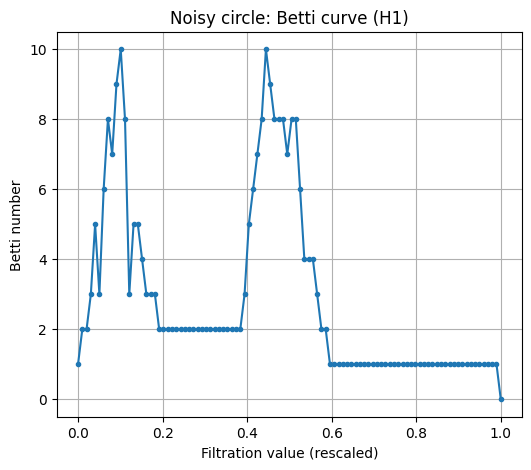

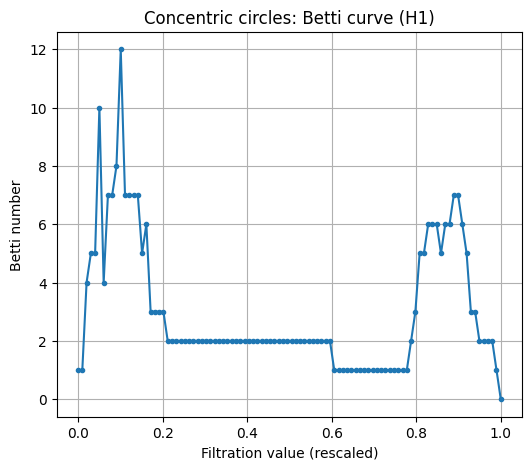

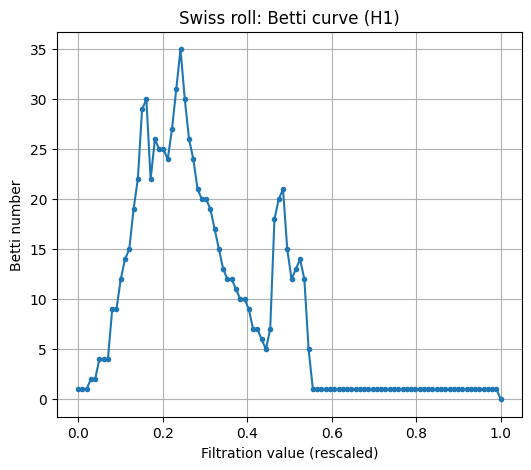

In [11]:
def plot_betti_curve(betti_curves, hom_dim=1, sample=0, title="Betti curve"):
    """
    betti_curves: array of shape (n_samples, n_homology_dimensions, n_bins)
    """
    curve = betti_curves[sample, hom_dim]
    xs = np.linspace(0, 1, curve.shape[-1])
    fig, ax = plt.subplots()
    ax.plot(xs, curve, "-o", markersize=3)
    ax.set_xlabel("Filtration value (rescaled)")
    ax.set_ylabel("Betti number")
    ax.set_title(title + f" (H{hom_dim})")
    plt.show()


plot_betti_curve(BC_circle, hom_dim=1, title="Noisy circle: Betti curve")
plot_betti_curve(BC_conc, hom_dim=1, title="Concentric circles: Betti curve")
plot_betti_curve(BC_swiss, hom_dim=1, title="Swiss roll: Betti curve")

### 1.5 Persistence Entropy

Persistence entropy quantifies the "disorder" or information content of a persistence diagram. For a persistence diagram $D$, the persistence entropy $E(D)$ is defined as:

$$
E(D) = -\sum_{(b,d) \in D} p_{(b,d)} \ln p_{(b,d)}
$$

where $p_{(b,d)} = \frac{(d-b)^2}{\sum_{(b',d') \in D} (d'-b')^2}$ is the normalized persistence (lifespan squared) of each topological feature.

- **Low entropy**: Few persistent features (ordered/crystal-like structure)
- **High entropy**: Many features with similar persistence (disordered structure)

This produces a single scalar value per dimension, making it ideal for classification tasks.

Persistence Entropy Results
Noisy circle    - H0: 7.7784, H1: 0.8901
Concentric circles - H0: 8.6600, H1: 4.3938
Swiss roll      - H0: 8.7789, H1: 6.5732


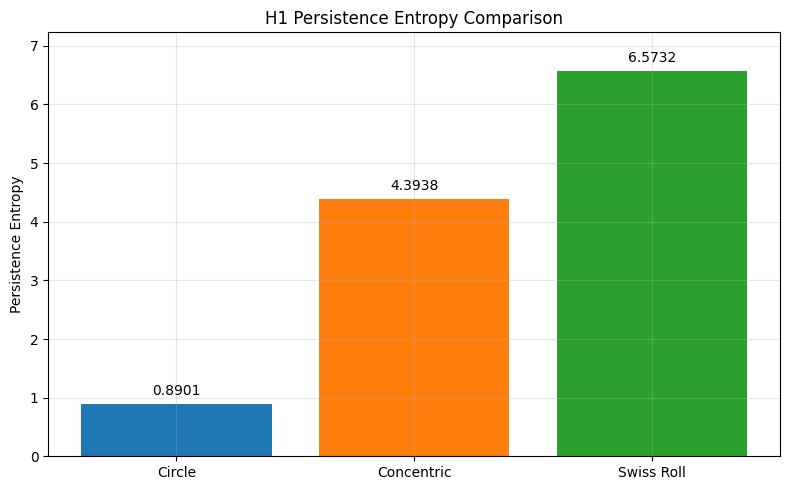

In [20]:
# 1.5 Persistence Entropy

vr = VietorisRipsPersistence(homology_dimensions=[0, 1])
diagrams = vr.fit_transform([X_outer, X_conc, X_swiss])

# Extract individual diagrams
diagramcircle = diagrams[0]
diagramconcentric = diagrams[1]
diagramswiss = diagrams[2]

# Compute persistence entropy
pe = PersistenceEntropy()
entropycircle = pe.fit_transform([diagramcircle])
entropyconcentric = pe.fit_transform([diagramconcentric])
entropysphere = pe.fit_transform([diagramswiss])

print("Persistence Entropy Results")
print(f"Noisy circle    - H0: {entropycircle[0][0]:.4f}, H1: {entropycircle[0][1]:.4f}")
print(f"Concentric circles - H0: {entropyconcentric[0][0]:.4f}, H1: {entropyconcentric[0][1]:.4f}")
print(f"Swiss roll      - H0: {entropysphere[0][0]:.4f}, H1: {entropysphere[0][1]:.4f}")

# Plot diagrams
fig1 = plot_diagram(diagramcircle, homology_dimensions=[1], 
                   plotly_params={"layout": {"title": "Noisy Circle H1"}})
fig1.show()

fig2 = plot_diagram(diagramconcentric, homology_dimensions=[1], 
                   plotly_params={"layout": {"title": "Concentric Circles H1"}})
fig2.show()

fig3 = plot_diagram(diagramswiss, homology_dimensions=[1], 
                   plotly_params={"layout": {"title": "Swiss Roll H1"}})
fig3.show()

# Bar plot comparing H1 entropy
datasets = ['Circle', 'Concentric', 'Swiss Roll']
h1_entropies = [entropycircle[0][1], entropyconcentric[0][1], entropysphere[0][1]]

plt.figure(figsize=(8, 5))
plt.bar(datasets, h1_entropies, color=['tab:blue', 'tab:orange', 'tab:green'])
plt.title('H1 Persistence Entropy Comparison')
plt.ylabel('Persistence Entropy')
plt.ylim(0, max(h1_entropies) * 1.1)
plt.grid(True, alpha=0.3)
for i, v in enumerate(h1_entropies):
    plt.text(i, v + 0.1, f'{v:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()